# Модель оценки рыночного риска портфеля — интерактивный ноутбук

Портфель: 5 ОФЗ (по 10 млн), 10 акций (по 1 млн), валюта (100 млн USD + 100 млн EUR) = 350 млн руб.

Воспроизводимость: `SEED=42`.

In [1]:
import sys; sys.path.append('src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
import config as C, data_loader as dl, risk_factors as rfm, dynamics as dyn
import pricing as pr, risk_measures as rm, backtesting as bt, bonus as bn, plots
rng = C.get_rng()
print('SEED =', C.SEED, '| Объём портфеля =', C.TOTAL_NOTIONAL/1e6, 'млн руб.')

SEED = 42 | Объём портфеля = 260.0 млн руб.


## 1 — Данные

In [2]:
panel = dl.build_panel()
print('Дней:', len(panel['dates']), '|', panel['dates'].min().date(), '—', panel['dates'].max().date())
panel['bond_meta'][['SHORTNAME','MATDATE','COUPONVALUE','COUPONPERCENT','FACEVALUE']]

Дней: 1271 | 2021-01-04 — 2025-12-30


,SHORTNAME,MATDATE,COUPONVALUE,COUPONPERCENT,FACEVALUE
SECID,,,,,
SU26218RMFS6,ОФЗ 26218,2031-09-17,42.38,8.50,1000.0
SU26224RMFS4,ОФЗ 26224,2029-05-23,34.41,6.90,1000.0
SU26230RMFS1,ОФЗ 26230,2039-03-16,38.39,7.70,1000.0
SU26231RMFS9,ОФЗ 26231,2044-07-20,1.25,0.25,1000.0
SU26233RMFS5,ОФЗ 26233,2035-07-18,30.42,6.10,1000.0


## 2 — Риск-факторы, PCA, описательная статистика

In [3]:
rf = rfm.build_risk_factors(panel)
print('Факторов:', rf['factors'].shape[1], '| PCA кривой объясняет',
      round(rf['pca'].explained_variance_ratio_.sum()*100,2), '% дисперсии')
print('Компоненты (уровень/наклон/кривизна):', (rf['pca'].explained_variance_ratio_*100).round(1))

Факторов: 15 | PCA кривой объясняет 95.72 % дисперсии
Компоненты (уровень/наклон/кривизна): [76.2 13.   6.5]


In [4]:
ds = rfm.descriptive_stats(rf)
ds[['std','skew','ex_kurtosis','ADF_p','JB_p']].round(4)

,std,skew,ex_kurtosis,ADF_p,JB_p
factor,,,,,
RatePC1,0.0067,-5.6818,151.2564,0.0,0.0
RatePC2,0.0027,-0.4659,7.8161,0.0,0.0
RatePC3,0.0019,0.2950,10.4970,0.0,0.0
ST_GAZP,0.0267,-2.8965,46.6424,0.0,0.0
ST_GMKN,0.0202,-0.0720,5.0856,0.0,0.0
ST_LKOH,0.0202,-1.6807,24.8717,0.0,0.0
ST_MGNT,0.0224,-2.5149,40.2764,0.0,0.0
ST_NVTK,0.0244,-0.9791,20.7070,0.0,0.0
ST_PLZL,0.0220,-1.5156,24.8487,0.0,0.0


In [5]:
# тяжесть хвостов и корреляции
display(rfm.tail_heaviness(rf).round(2))
rfm.correlation_matrix(rf).round(2)

,ex_kurtosis,hill_alpha
factor,,
RatePC1,151.26,1.99
RatePC2,7.82,2.79
RatePC3,10.50,2.49
ST_GAZP,46.64,2.10
ST_GMKN,5.09,3.92
ST_LKOH,24.87,2.94
ST_MGNT,40.28,2.82
ST_NVTK,20.71,3.23
ST_PLZL,24.85,3.27


,RatePC1,RatePC2,RatePC3,ST_GAZP,ST_GMKN,ST_LKOH,ST_MGNT,ST_NVTK,ST_PLZL,ST_ROSN,ST_SBER,ST_SNGS,ST_TATN,FX_USD,FX_EUR
RatePC1,1.00,0.00,-0.00,0.32,0.25,0.33,0.37,0.34,0.31,0.48,0.44,0.34,0.39,-0.12,-0.12
RatePC2,0.00,1.00,-0.00,-0.15,-0.15,-0.13,-0.20,-0.14,-0.10,-0.16,-0.15,-0.13,-0.14,0.10,0.09
RatePC3,-0.00,-0.00,1.00,0.07,0.03,0.05,0.04,0.07,0.11,0.08,0.07,0.06,0.10,-0.05,-0.05
ST_GAZP,0.32,-0.15,0.07,1.00,0.54,0.58,0.52,0.56,0.42,0.62,0.62,0.54,0.61,-0.06,-0.06
ST_GMKN,0.25,-0.15,0.03,0.54,1.00,0.54,0.53,0.60,0.45,0.58,0.57,0.55,0.58,0.02,0.01
ST_LKOH,0.33,-0.13,0.05,0.58,0.54,1.00,0.57,0.64,0.43,0.71,0.63,0.56,0.67,-0.02,-0.02
ST_MGNT,0.37,-0.20,0.04,0.52,0.53,0.57,1.00,0.54,0.45,0.64,0.63,0.57,0.60,-0.07,-0.07
ST_NVTK,0.34,-0.14,0.07,0.56,0.60,0.64,0.54,1.00,0.42,0.70,0.66,0.60,0.67,-0.05,-0.06
ST_PLZL,0.31,-0.10,0.11,0.42,0.45,0.43,0.45,0.42,1.00,0.52,0.46,0.47,0.48,-0.03,-0.02
ST_ROSN,0.48,-0.16,0.08,0.62,0.58,0.71,0.64,0.70,0.52,1.00,0.73,0.67,0.76,-0.04,-0.04


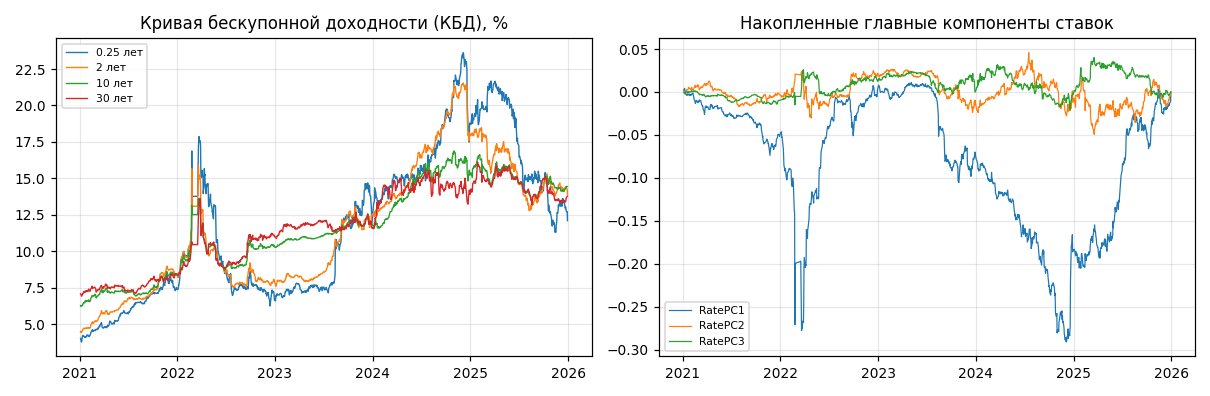

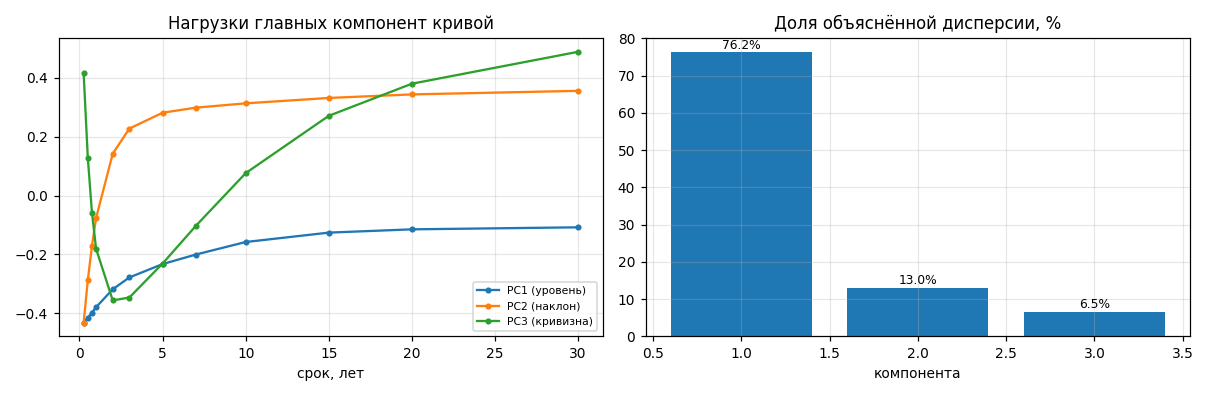

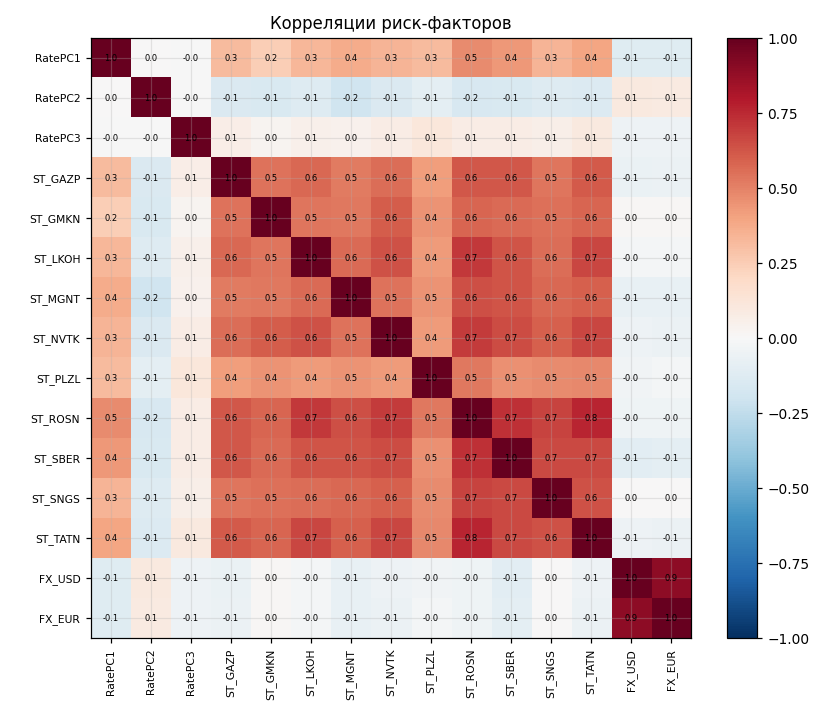

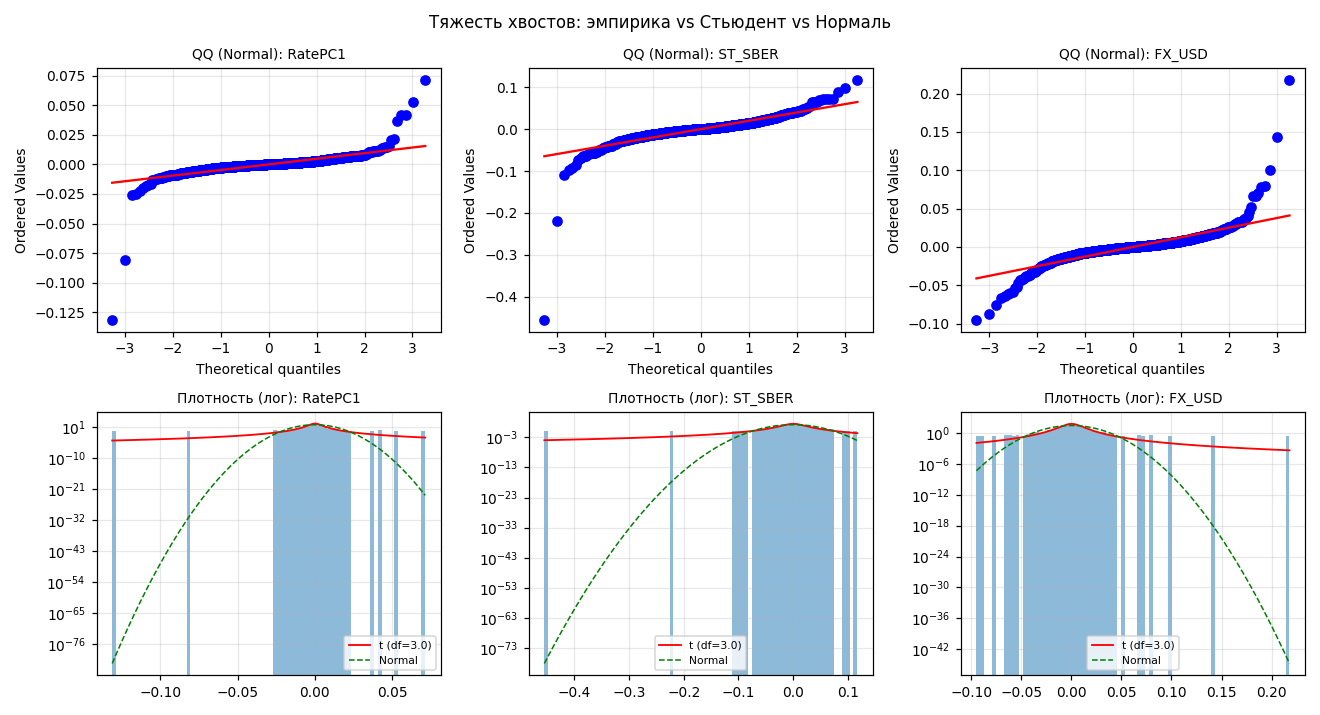

In [6]:
# Графики п.2c
plots.make_all(panel, rf, dyn.fit_marginals(rf['factors']))
from IPython.display import Image, display
for f in ['fig_rates_history','fig_pca_loadings','fig_corr_heatmap','fig_tails']:
    display(Image(C.OUT_DIR+f'/{f}.png'))

## 3 — Модели динамики (MLE) и копула

In [7]:
marg = dyn.fit_marginals(rf['factors'])
mtab = dyn.marginals_table(marg)
print('t лучше нормали по AIC:', int(mtab['t_better'].sum()), 'из', len(mtab))
mtab[['t_df','t_scale','AIC_t','AIC_norm','t_better']].round(3)

t лучше нормали по AIC: 15 из 15


,t_df,t_scale,AIC_t,AIC_norm,t_better
factor,,,,,
RatePC1,3.000,0.002,-10661.191,-9124.749,True
RatePC2,3.000,0.002,-11784.562,-11372.306,True
RatePC3,3.000,0.001,-12715.904,-12246.550,True
ST_GAZP,3.000,0.013,-6422.277,-5593.490,True
ST_GMKN,3.278,0.013,-6514.439,-6307.791,True
ST_LKOH,3.000,0.012,-6759.199,-6303.090,True
ST_MGNT,3.043,0.013,-6508.574,-6041.325,True
ST_NVTK,3.313,0.015,-6164.382,-5823.806,True
ST_PLZL,3.433,0.014,-6433.644,-6091.287,True


In [8]:
R = dyn.gaussian_copula_corr(rf['factors'], marg)
pd.DataFrame(R, index=rf['factors'].columns, columns=rf['factors'].columns).round(2)

,RatePC1,RatePC2,RatePC3,ST_GAZP,ST_GMKN,ST_LKOH,ST_MGNT,ST_NVTK,ST_PLZL,ST_ROSN,ST_SBER,ST_SNGS,ST_TATN,FX_USD,FX_EUR
RatePC1,1.00,0.05,-0.18,0.17,0.14,0.12,0.14,0.13,0.12,0.17,0.17,0.14,0.15,-0.07,-0.06
RatePC2,0.05,1.00,0.03,-0.15,-0.18,-0.15,-0.21,-0.16,-0.11,-0.18,-0.19,-0.15,-0.17,0.10,0.08
RatePC3,-0.18,0.03,1.00,-0.01,-0.01,-0.02,-0.01,-0.01,0.06,-0.04,-0.03,-0.01,0.00,-0.03,-0.04
ST_GAZP,0.17,-0.15,-0.01,1.00,0.57,0.57,0.50,0.58,0.33,0.59,0.61,0.57,0.60,-0.01,-0.03
ST_GMKN,0.14,-0.18,-0.01,0.57,1.00,0.51,0.47,0.56,0.38,0.53,0.56,0.54,0.52,0.04,0.03
ST_LKOH,0.12,-0.15,-0.02,0.57,0.51,1.00,0.50,0.60,0.32,0.66,0.57,0.55,0.62,0.05,0.03
ST_MGNT,0.14,-0.21,-0.01,0.50,0.47,0.50,1.00,0.48,0.34,0.52,0.53,0.50,0.51,-0.01,-0.03
ST_NVTK,0.13,-0.16,-0.01,0.58,0.56,0.60,0.48,1.00,0.32,0.63,0.61,0.57,0.58,0.02,-0.01
ST_PLZL,0.12,-0.11,0.06,0.33,0.38,0.32,0.34,0.32,1.00,0.36,0.34,0.36,0.33,0.02,0.03
ST_ROSN,0.17,-0.18,-0.04,0.59,0.53,0.66,0.52,0.63,0.36,1.00,0.61,0.60,0.67,0.05,0.02


## 4 — Справедливая стоимость и точность

In [9]:
asof = pd.Timestamp(C.RISK_DATE)
acc = pr.bond_pricing_accuracy(panel, dates=[asof])
display(acc[['SECID','model','market','err_rub','err_pct_face']].round(2))
print('z-спреды (модель=рынок), %:'); pr.calibrate_bond_spreads(panel, asof).mul(100).round(3)

,SECID,model,market,err_rub,err_pct_face
0,SU26218RMFS6,760.57,797.81,-37.24,-3.72
1,SU26224RMFS4,780.22,812.07,-31.85,-3.18
2,SU26230RMFS1,607.23,638.50,-31.27,-3.13
3,SU26231RMFS9,94.73,NaN,NaN,NaN
4,SU26233RMFS5,575.97,606.23,-30.26,-3.03


z-спреды (модель=рынок), %:


SU26218RMFS6   -1.086
SU26224RMFS4   -1.295
SU26230RMFS1   -0.716
SU26231RMFS9    0.000
SU26233RMFS5   -0.809
dtype: float64

## 5 — VaR (99%) и ES (97.5%) на 02.12.2025

In [10]:
rep = rm.build_repricer(panel, rf, asof)
for h in C.HORIZONS:
    rr = rm.risk_report(rep, rf['factors'], marg, R, h, C.N_SIM, rng)
    print(f'\n=== Горизонт {h} дн. (руб.) ===')
    display(rr.round(0))


=== Горизонт 1 дн. (руб.) ===


,horizon,VaR_99,ES_975,mean_PnL,std_PnL
sub,,,,,
total,1,5786368.0,6407759.0,938.0,2436853.0
bonds,1,1070832.0,1149153.0,-25071.0,400396.0
stocks,1,405552.0,427594.0,329.0,158989.0
fx,1,5755981.0,6402614.0,25679.0,2426124.0



=== Горизонт 10 дн. (руб.) ===


,horizon,VaR_99,ES_975,mean_PnL,std_PnL
sub,,,,,
total,10,16754886.0,17557287.0,18134.0,6981393.0
bonds,10,3356713.0,3475993.0,-237045.0,1294268.0
stocks,10,1187796.0,1201293.0,4757.0,499563.0
fx,10,16653912.0,17354437.0,250423.0,6927650.0


## 6–7 — Бэктест и тесты

,n_days,breaches,breach_rate,expected_rate,expected_breaches
sub,,,,,
total,254,1,0.00,0.01,2.54
bonds,254,3,0.01,0.01,2.54
stocks,254,2,0.01,0.01,2.54
fx,254,2,0.01,0.01,2.54


,breaches,expected,Kupiec_p,Kupiec_ok,Christ_ind_p,Christ_cc_p,Christ_cc_ok,DQ_p,DQ_ok
sub,,,,,,,,,
total,1,2.5,0.2684,True,0.9290,0.5398,True,0.9854,True
stocks,2,2.5,0.7236,True,0.8583,0.9245,True,0.9963,True
bonds,3,2.5,0.7779,True,0.7884,0.9270,True,0.8478,True
fx,2,2.5,0.7236,True,0.8583,0.9245,True,0.9998,True


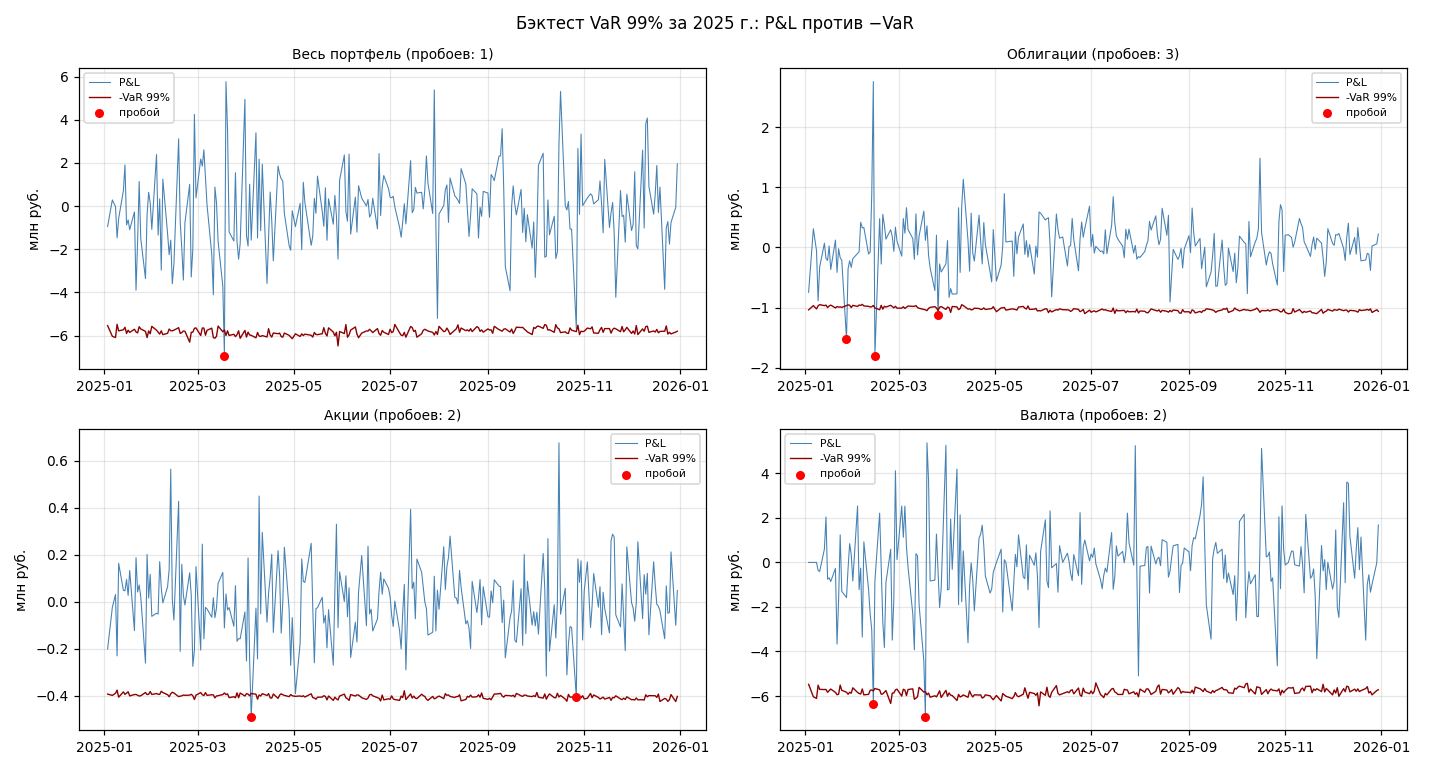

In [11]:
btab = bt.run_backtest(panel, verbose=False)
display(bt.breach_summary(btab).round(2))
display(bt.run_all_tests(btab))
from IPython.display import Image, display
plots.fig_backtest(btab, C.OUT_DIR+'/fig_backtest.png')
display(Image(C.OUT_DIR+'/fig_backtest.png'))

## 8 — Бонус: опционы (Блэк-76) и облигации со встроенными опционами

In [12]:
o = bn.price_option_portfolio(panel)
print(f"F={o['F']:.0f}, T={o['T']:.3f}, calib σ={o['sigma']:.3f}")
display(o['observed'][['SECID','TYPE','STRIKE','PRICE','impl_vol','model_price']].round(2))
e = bn.price_embedded_option_bonds(panel)
print(f"{e['sid']}: обычная={e['plain']:.2f}  putable={e['putable']:.2f} (+{e['putable_premium']:.2f})  "
      f"callable={e['callable']:.2f} (-{e['callable_discount']:.2f}) руб.")

F=279775, T=0.170, calib σ=0.314


,SECID,TYPE,STRIKE,PRICE,impl_vol,model_price
0,MX265000BL5,C,265000,22125.0,0.31,22125.0
1,MX265000BW5,P,265000,3850.0,0.21,3850.0


SU26224RMFS4: обычная=812.07  putable=989.20 (+177.13)  callable=812.07 (-0.00) руб.
